In [1]:
import os,pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC,SVC
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.ensemble import RandomForestClassifier
import shap

from project_package.visualization import Model_Visualizer
from project_package import utility,evaluation,modeling

g:\Python\envs\learning_env\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# choose to test either full version or lite version
use_lite_version = True
if use_lite_version:
    base_directory = 'supervised_lite'
else:
    base_directory = 'supervised'

#### Problem 1: Classification (booking completion vs cancellation)

In [3]:
files = os.listdir(base_directory)

file = [item for item in files if 'Booking Value_fill_scaled.pkl' in item][-1]

model_path = os.path.join(base_directory, file)

with open(model_path, "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('pre',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000240F746D8E0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000240F746D190>)])),
                ('reg', Ridge(alpha=3.0))])

Load the train and test data

In [4]:
split_df = pd.read_csv(os.path.join(base_directory, 'split_assignments_regression_Booking_Value_fill_scaled.csv'))

if use_lite_version:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short__top20_s30.csv')
else:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short.csv')

In [16]:
if use_lite_version:
    # train data
    train_data = modeling.drop_unnecessary_cols(
        model_data.loc[split_df.loc[split_df.split=='train'].index],
        'Value_fill_scaled')
    # validation data
    test_data = modeling.drop_unnecessary_cols(
        model_data.loc[split_df.loc[split_df.split=='valid'].index],
        'Value_fill_scaled')
else:
    # train data
    train_data = modeling.drop_unnecessary_cols(
        model_data.loc[split_df.loc[split_df.split=='train'].index],
        'Value_fill_scaled')
    # validation data
    test_data = modeling.drop_unnecessary_cols(
        model_data.loc[split_df.loc[split_df.split=='valid'].index],
        'Value_fill_scaled')

y_train = split_df.loc[split_df.split=='train']['Booking Value_fill_scaled']
y_test = split_df.loc[split_df.split=='valid']['Booking Value_fill_scaled']

In [17]:
## check model score
prediction_df = pd.read_csv(f'{base_directory}/cls_best_rf_preds.csv')

print('---------on training dataset--------------')
print('MAE from model:',mean_absolute_error(y_train,model.predict(train_data)))
print()
print('MSE from model:',mean_squared_error(y_train,model.predict(train_data)))

print()
print('---------on test dataset--------------')
print('MAE from model:',mean_absolute_error(y_test,model.predict(test_data)))
print('MAE from file:',mean_absolute_error(y_test,prediction_df.y_pred))
print()
print('MSE from model:',mean_squared_error(y_test,model.predict(test_data)))
print('MSE from file:',mean_squared_error(y_test,prediction_df.y_pred))

---------on training dataset--------------
MAE from model: 0.9729457277050725

MSE from model: 2.586748161127138

---------on test dataset--------------
MAE from model: 0.9509038168326801
MAE from file: 1.3358002041590507

MSE from model: 2.483524877893243
MSE from file: 3.1590129756079306


In [ ]:
reg_vis_obj = Model_Visualizer(
    # train_data.to_numpy(),
    # test_data.to_numpy(),
    train_data,
    test_data,
    y_train,
    y_test,
    # feature_names=train_data.columns
    feature_names = model[0].get_feature_names_out()
    )

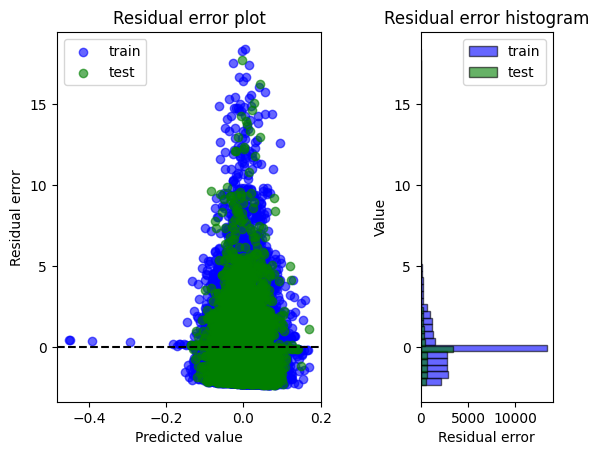

In [11]:
reg_vis_obj.residual_plot(model,bins=50)

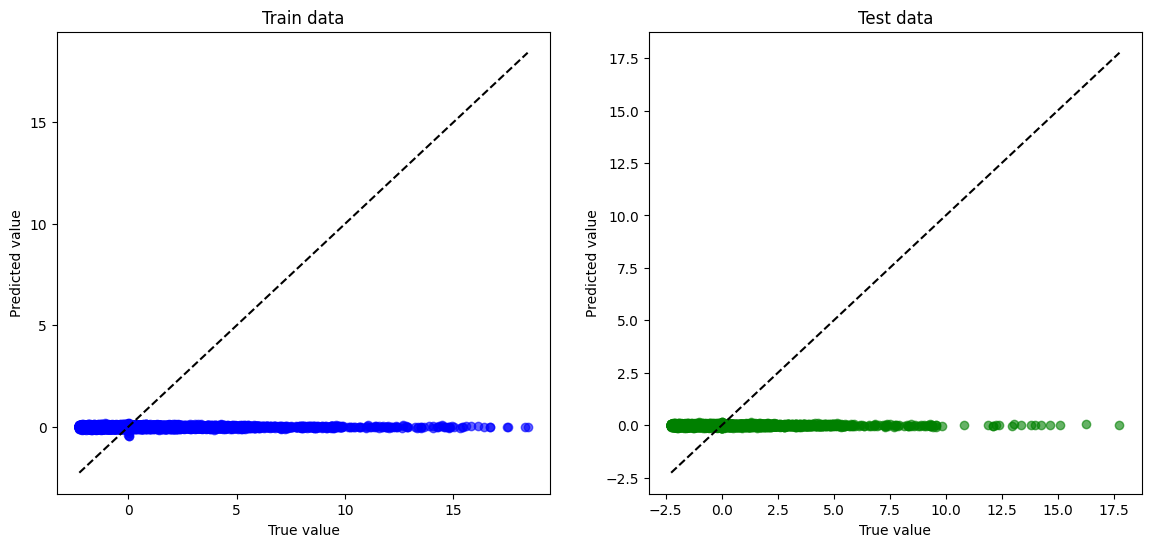

In [12]:
reg_vis_obj.prediction_validate_plot(model)